# IBL 2AFC dataset exploration

*Auxiliary notebook for the QMN TA team*

Loads `notebooks/data/ibl_2afc.csv.gz` (built by `data_prep/build_ibl_dataset.py`
from the public IBL release https://www.internationalbrainlab.com/data) and
walks through what is in it, so we can design Notebooks 3-8 having the content
clear in mind (potentially at some point we could extend it with the ephys
data that come with it for the Notebooks beyond 8).

**Full column documentation:** `notebooks/data/ibl_2afc_datadictionary.md`.

Key facts to keep in mind:

- **30 mice** in a 10 / 10 / 10 design doing a 2AFC visual discrimination task
  (`https://doi.org/10.7554/eLife.63711`): 10 wild-type from the Churchland lab
  (`CSHL…`), 10 wild-type from the Angelaki lab (`NYU-…`), and 10 **Cntnap2**
  ASD-model mice from the Angelaki lab (`CSP…`). The `group` (`WT`/`ASD`) and
  `genotype` columns of the subject table carry this.
- The difficulty variable is **`signed_contrast`**: the contrast of a Gabor
  grating (positive = stimulus on the right). It is **not** motion coherence.
- **`response`**: `1` = chose right, `0` = chose left, `NaN` = no-go. (The
  underlying IBL `choice` field uses −1 = right, +1 = left; the build script
  remaps and self-validates it.)
- **`reaction_time_s`** is kept **raw**: it contains negative and out-of-range
  values on purpose (a data-cleaning teaching exercise). IBL's valid window is
  [0.08, 2.0] s.
- **`no_go`** trials (i.e. trials in which the animal ignored the task) are kept,
  again we could use it as data cleaning exercise.
- **§9 is the main result.** Within the Angelaki lab the Cntnap2 (ASD) mice rely
  on the block prior less than the wild-type mice (a significant difference, as in
  Noel, Angelaki et al. 2025). The same per-mouse number also gives a small
  lab difference (the two wild-type cohorts, CSHL vs NYU) and a clear
  non-difference (males vs females), which we use as examples in the stats notebooks.


In [1]:
# --- Imports + plot style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = {"training": "#ff7f0e", "trained": "#1f77b4"}
SESSION_CMAP = LinearSegmentedColormap.from_list(
    "blue_orange", ["#08519c", "#bdbdbd", "#ff7f0e"])


In [2]:
# --- Load the data: the trial table + its companion subject-metadata table
df       = pd.read_csv("../notebooks/data/ibl_2afc.csv.gz")
subjects = pd.read_csv("../notebooks/data/ibl_2afc_subjects.csv")

# the three cohorts used throughout: two wild-type labs + the ASD line
subjects["cohort"] = np.where(subjects["lab"] == "churchlandlab", "CSHL-WT",
                      np.where(subjects["group"] == "WT", "NYU-WT", "CSP-ASD"))

# bring the subject-level factors (group / genotype / lab / cohort) onto every trial
df = df.merge(subjects[["subject_id", "group", "genotype", "lab", "cohort"]],
              on="subject_id")

print("trials   :", df.shape)
print("subjects :", subjects.shape)
print("phases   :", sorted(df["phase"].unique()))
print("cohorts  :", subjects["cohort"].value_counts().to_dict())

# Per-mouse colours, one colour family per cohort:
#   Churchland WT = blues, Angelaki WT = oranges, Angelaki ASD = reds.
MOUSE_COLOR = {}
for coh, cmap_name in [("CSHL-WT", "Blues"), ("NYU-WT", "Oranges"), ("CSP-ASD", "Reds")]:
    coh_mice = sorted(subjects.loc[subjects["cohort"] == coh, "subject_id"])
    shades = plt.get_cmap(cmap_name)(np.linspace(0.45, 0.92, len(coh_mice)))
    MOUSE_COLOR.update(zip(coh_mice, shades))

# Solid cohort colours for the group comparisons (§9), same families.
COHORT_COLOR = {"CSHL-WT": "#1f77b4", "NYU-WT": "#ff7f0e", "CSP-ASD": "#d62728"}

df.tail(10)


trials   : (694182, 23)
subjects : (30, 10)
phases   : ['trained', 'training']
cohorts  : {'CSHL-WT': 10, 'CSP-ASD': 10, 'NYU-WT': 10}


,trial_id,subject_id,phase,session,trial_in_session,signed_contrast,stimulus_side,response,correct,no_go,...,reward_volume,stim_on_time_s,go_cue_time_s,first_movement_time_s,choice_time_s,feedback_time_s,group,genotype,lab,cohort
694172,694172,CSP013,trained,8,649,0.2500,right,1.0,1.0,False,...,1.5,3717.2712,3717.2721,3719.0548,3719.2642,3719.2643,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694173,694173,CSP013,trained,8,650,0.1250,right,1.0,1.0,False,...,1.5,3722.5810,3722.5820,3726.2368,3726.4971,3726.4972,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694174,694174,CSP013,trained,8,651,0.1250,right,1.0,1.0,False,...,1.5,3729.5711,3729.5723,3741.7758,3742.0404,3742.0405,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694175,694175,CSP013,trained,8,652,1.0000,right,1.0,1.0,False,...,1.5,3745.6036,3745.6044,3745.9528,3746.2601,3746.2602,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694176,694176,CSP013,trained,8,653,0.0000,zero,0.0,1.0,False,...,1.5,3749.5034,3749.5044,3749.7108,3749.8589,3749.8590,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694177,694177,CSP013,trained,8,654,1.0000,right,1.0,1.0,False,...,1.5,3754.6306,3754.6317,3761.4028,3761.7888,3761.7889,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694178,694178,CSP013,trained,8,655,0.2500,right,1.0,1.0,False,...,1.5,3765.0971,3765.0979,3772.5398,3772.6800,3772.6801,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694179,694179,CSP013,trained,8,656,1.0000,right,1.0,1.0,False,...,1.5,3776.4802,3776.4811,3782.1208,3782.3550,3782.3551,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694180,694180,CSP013,trained,8,657,0.0625,right,0.0,0.0,False,...,0.0,3790.1967,3790.1976,3796.1108,3796.2277,3796.2289,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD
694181,694181,CSP013,trained,8,658,0.2500,right,1.0,1.0,False,...,1.5,3800.4696,3800.4705,3835.6968,3837.9098,3837.9099,ASD,Cntnap2 (ASD model),angelakilab,CSP-ASD


## Companion table: subject metadata (`ibl_2afc_subjects.csv`)

One row per mouse: lab, institution, sex, age and project. It is the subject-level companion to the trial-level table above; the two join on `subject_id`. This is what a real experimental **metadata table** looks like (and it adds sex, lab and age as genuine factors for later analyses).

In [3]:
# --- Inspect the subject-metadata table (30 mice: 10 CSHL-WT + 10 NYU-WT + 10 CSP-ASD)
subjects


,subject_id,group,genotype,lab,institution,sex,birth_date,age_weeks_at_first_session,project,cohort
0,CSHL045,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-08-06,13,ibl_neuropixel_brainwide_01,CSHL-WT
1,CSHL046,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-08-06,13,ibl_neuropixel_brainwide_01,CSHL-WT
2,CSHL047,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-08-06,13,ibl_neuropixel_brainwide_01,CSHL-WT
3,CSHL049,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-08-06,13,ibl_neuropixel_brainwide_01,CSHL-WT
4,CSHL051,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,F,2019-08-13,13,ibl_neuropixel_brainwide_01,CSHL-WT
5,CSHL053,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,F,2019-08-13,13,ibl_neuropixel_brainwide_01,CSHL-WT
6,CSHL054,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,F,2019-08-13,13,ibl_neuropixel_brainwide_01,CSHL-WT
7,CSHL055,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,F,2019-08-13,13,ibl_neuropixel_brainwide_01,CSHL-WT
8,CSHL059,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-10-15,14,ibl_neuropixel_brainwide_01,CSHL-WT
9,CSHL060,WT,wild-type,churchlandlab,Cold Spring Harbor Laboratory,M,2019-10-15,14,ibl_neuropixel_brainwide_01,CSHL-WT


## 1. Dataset shape: trials per subject and session

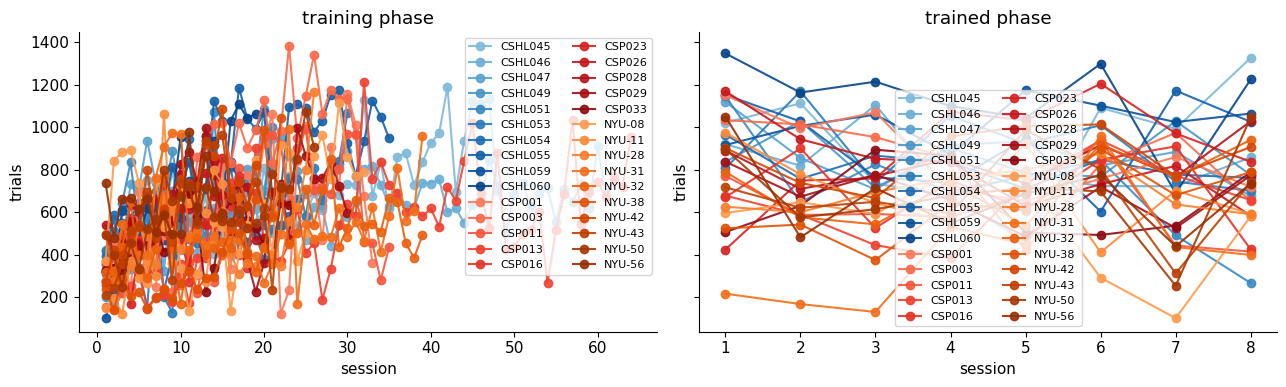

In [4]:
# --- Trials per subject per session, per phase
counts = df.groupby(["phase", "subject_id", "session"]).size().rename("n_trials").reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, phase in zip(axes, ["training", "trained"]):
    for subj, g in counts[counts["phase"] == phase].groupby("subject_id"):
        ax.plot(g["session"], g["n_trials"], "o-", color=MOUSE_COLOR[subj],
                label=subj, alpha=0.9)
    ax.set_title(f"{phase} phase"); ax.set_xlabel("session"); ax.set_ylabel("trials")
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 2. Accuracy across signed contrast levels (Psychometric curves)

Empirical **P(response = right)** as a function of **signed contrast**.

**Trained phase**: the mouse is at stable expert performance, so the 8 sessions
can be pooled into one clean psychometric curve per mouse.

**Training phase**: pooling is *not* valid here. During training the IBL
pipeline introduces contrasts progressively (100 % and 50 % first; then 25 %,
12.5 %, 6.25 %, 0 % added over later sessions) *and* the mouse is still learning.
A psychometric pooled over all training sessions therefore mixes a changing
animal with a changing stimulus set, producing a spurious non-monotonic
("U-shaped") curve (the high-contrast bins are diluted by naive early-session
trials while the low-contrast bins exist only in late sessions). So we show the
training psychometric **per session**: each curve is then a clean, well-defined
snapshot. Early sessions (dark) are shallow with few contrasts; later sessions
(light) steepen as the mouse learns and the contrast set grows.

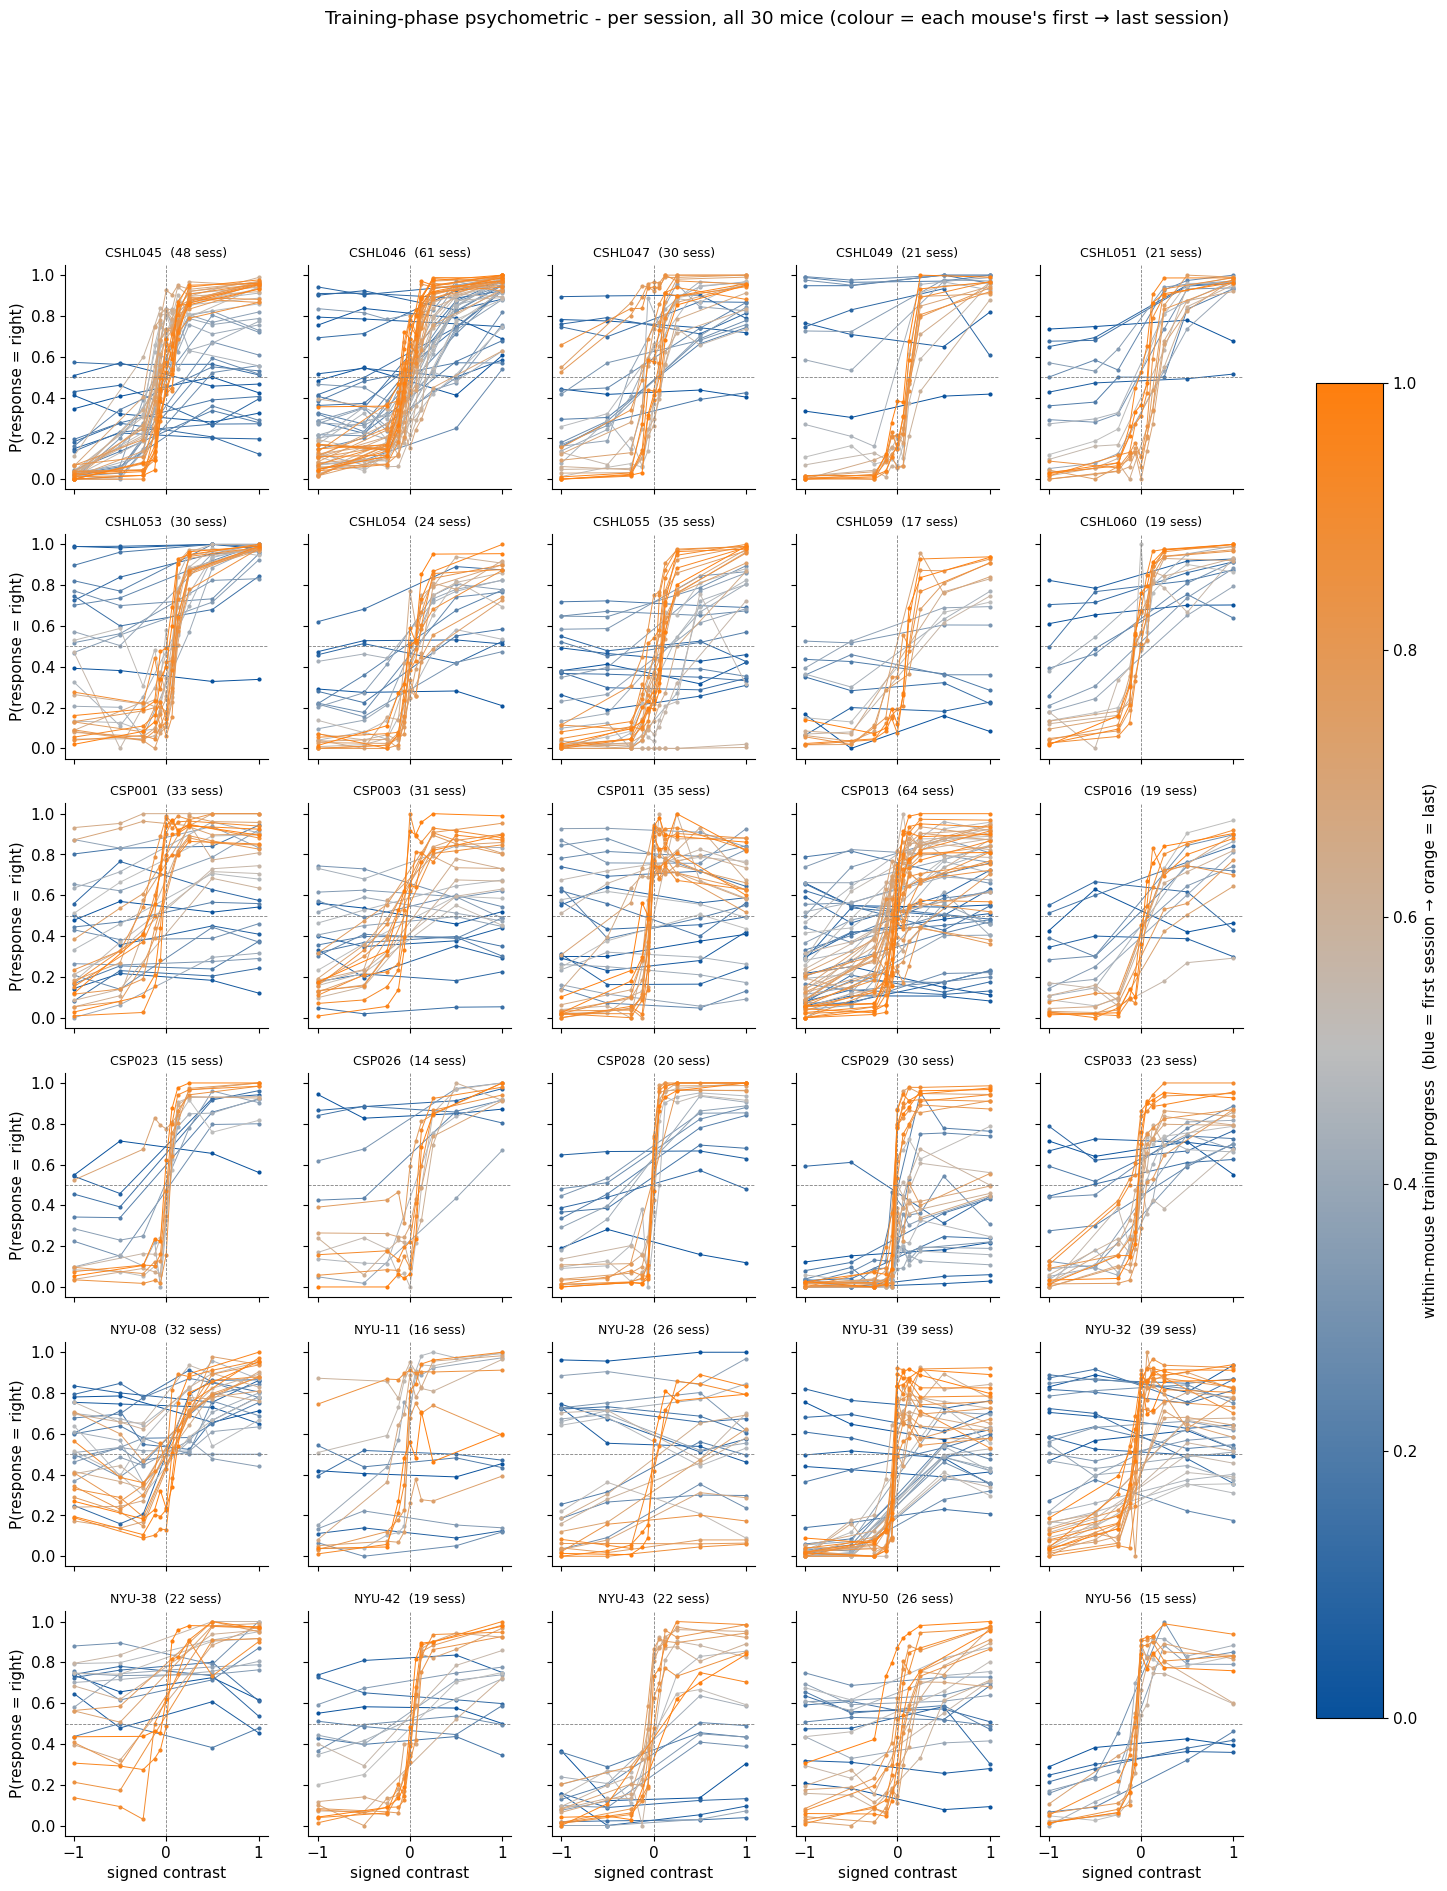

In [5]:
# --- Training psychometric, per session (colour = within-mouse progress)
train = df[(df["phase"] == "training") & df["response"].notna()]
mice = sorted(train["subject_id"].unique())

ncols = 5
nrows = int(np.ceil(len(mice) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(19, 3.4 * nrows),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)
for ax, subj in zip(axes.flat, mice):
    g = train[train["subject_id"] == subj]
    smax = int(g["session"].max())
    for sess, gs in g.groupby("session"):
        frac = (sess - 1) / max(smax - 1, 1)   # 0 = first session, 1 = last
        psy = gs.groupby("signed_contrast")["response"].mean()
        ax.plot(psy.index, psy.values, "o-", ms=2, lw=0.7, color=SESSION_CMAP(frac))
    ax.axhline(0.5, color="gray", lw=0.6, ls="--")
    ax.axvline(0.0, color="gray", lw=0.6, ls="--")
    ax.set_title(f"{subj}  ({smax} sess)", fontsize=9)
for ax in axes.flat[len(mice):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("signed contrast")
for ax in axes[:, 0]:
    ax.set_ylabel("P(response = right)")

sm = plt.cm.ScalarMappable(cmap=SESSION_CMAP, norm=plt.Normalize(0, 1))
fig.colorbar(sm, ax=axes, shrink=0.85,
             label="within-mouse training progress  (blue = first session → orange = last)")
fig.suptitle(f"Training-phase psychometric - per session, all {len(mice)} mice "
             f"(colour = each mouse's first → last session)", y=1.005)
plt.show()


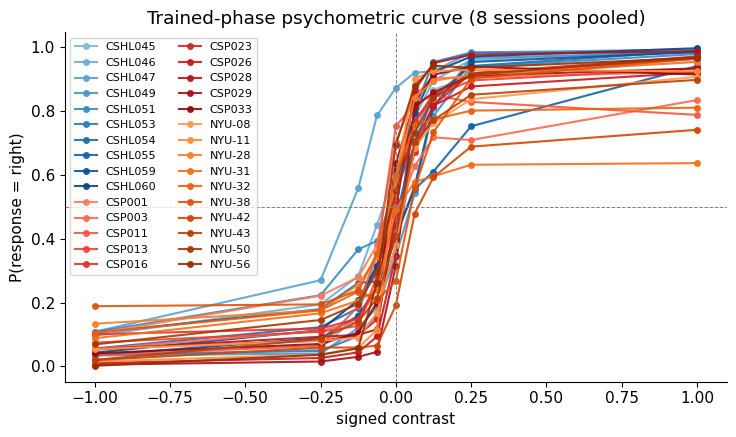

In [6]:
# --- Trained psychometric, pooled across the 8 sessions
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sub = df[(df["phase"] == "trained") & df["response"].notna()]
for subj, g in sub.groupby("subject_id"):
    psy = g.groupby("signed_contrast")["response"].mean()
    ax.plot(psy.index, psy.values, "o-", ms=4, color=MOUSE_COLOR[subj],
            alpha=0.9, label=subj)
ax.axhline(0.5, color="gray", lw=0.7, ls="--")
ax.axvline(0.0, color="gray", lw=0.7, ls="--")
ax.set_title("Trained-phase psychometric curve (8 sessions pooled)")
ax.set_xlabel("signed contrast"); ax.set_ylabel("P(response = right)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 3. Accuracy across sessions (Learning curves)

Mean accuracy per session. The training phase now keeps each mouse's whole
`trainingChoiceWorld` history, so we see the full learning curve: from around
chance (50 %) up to proficiency. Mice learn at very different speeds (some take
~15 sessions, some 60+), which is why the training curves have different lengths.
The trained phase (right) is already near asymptote.

One thing to notice: the last training sessions sit a bit *higher* than the
trained phase. That is expected, because the two phases are different tasks and
not contiguous. `trainingChoiceWorld` is the easier one; the trained
`biasedChoiceWorld` task adds the low and zero contrasts and the bias blocks,
which drags the mean accuracy down even for an expert mouse. So the lower trained
accuracy is about a harder task, not a worse animal.


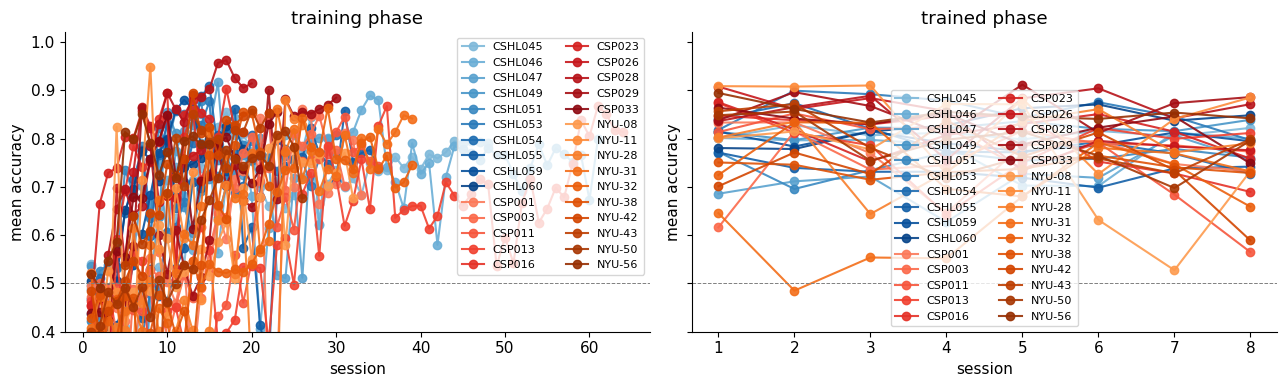

In [7]:
# --- Mean accuracy per session per subject
acc = (df.dropna(subset=["correct"])
         .groupby(["phase", "subject_id", "session"])["correct"].mean().reset_index())
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, phase in zip(axes, ["training", "trained"]):
    for subj, g in acc[acc["phase"] == phase].groupby("subject_id"):
        ax.plot(g["session"], g["correct"], "o-", color=MOUSE_COLOR[subj],
                label=subj, alpha=0.9)
    ax.axhline(0.5, color="gray", lw=0.7, ls="--")
    ax.set_title(f"{phase} phase"); ax.set_xlabel("session"); ax.set_ylabel("mean accuracy")
    ax.set_ylim(0.4, 1.02); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 4. Reaction times: idea of data-cleaning exercise

`reaction_time_s` (first wheel movement − stimulus onset) is shipped uncleaned.
The dashed lines mark IBL's valid analysis window **[0.08, 2.0] s**. Note the
mass of trials at negative / sub-80 ms values (movements that began before or
too soon after stimulus onset to be genuine responses).


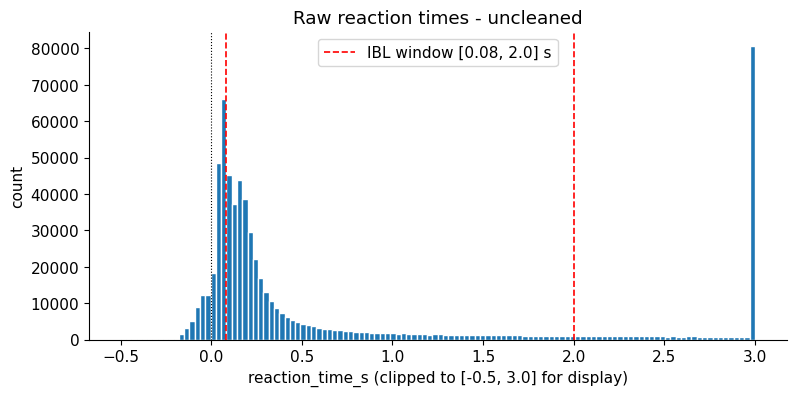

negative reaction_time_s     :  45130  (6.5%)
in IBL window [0.08, 2.0] s  : 385089  (55.5%)
NaN reaction_time_s          :  30761  (4.4%)


In [8]:
# --- Raw reaction-time distribution, with the IBL validity window
rt = df["reaction_time_s"].dropna()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rt.clip(-0.5, 3.0), bins=120, color="C0", edgecolor="white")
ax.axvline(0.08, color="red", lw=1.2, ls="--", label="IBL window [0.08, 2.0] s")
ax.axvline(2.0,  color="red", lw=1.2, ls="--")
ax.axvline(0.0,  color="black", lw=0.8, ls=":")
ax.set_xlabel("reaction_time_s (clipped to [-0.5, 3.0] for display)")
ax.set_ylabel("count"); ax.set_title("Raw reaction times - uncleaned")
ax.legend()
plt.show()

n = len(df)
print(f"negative reaction_time_s     : {(df['reaction_time_s'] < 0).sum():>6}  ({(df['reaction_time_s'] < 0).mean()*100:.1f}%)")
print(f"in IBL window [0.08, 2.0] s  : {((df['reaction_time_s']>=0.08)&(df['reaction_time_s']<=2.0)).sum():>6}  ({((df['reaction_time_s']>=0.08)&(df['reaction_time_s']<=2.0)).mean()*100:.1f}%)")
print(f"NaN reaction_time_s          : {df['reaction_time_s'].isna().sum():>6}  ({df['reaction_time_s'].isna().mean()*100:.1f}%)")


## 5. Reaction time vs response time

`reaction_time_s` = time to *start* moving; `response_time_s` = time to
*complete* the choice. Restricting to the IBL-valid reaction-time window for
this comparison. Cell below is a sanity check.


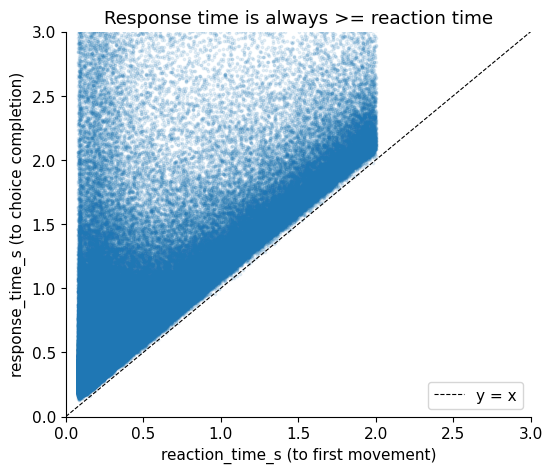

In [9]:
# --- reaction vs response time (valid-RT trials only)
valid = df[(df["reaction_time_s"] >= 0.08) & (df["reaction_time_s"] <= 2.0)]
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid["reaction_time_s"], valid["response_time_s"], s=3, alpha=0.1, color="C0")
lim = [0, 3]
ax.plot(lim, lim, "k--", lw=0.8, label="y = x")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("reaction_time_s (to first movement)")
ax.set_ylabel("response_time_s (to choice completion)")
ax.set_title("Response time is always >= reaction time")
ax.legend()
plt.show()


## 6. Bias-block effect (trained phase)

In the trained phase, `probability_left` switches between blocks. The block
prior shifts the psychometric curve laterally (strongest at 0% contrast), where
the mouse has no visual evidence and must rely on the prior (the prior is 
learned by the mice over time experiencing alternation of blocks biased on 
one side or the other). This could be a natural place where to plug some 
statistical testing.


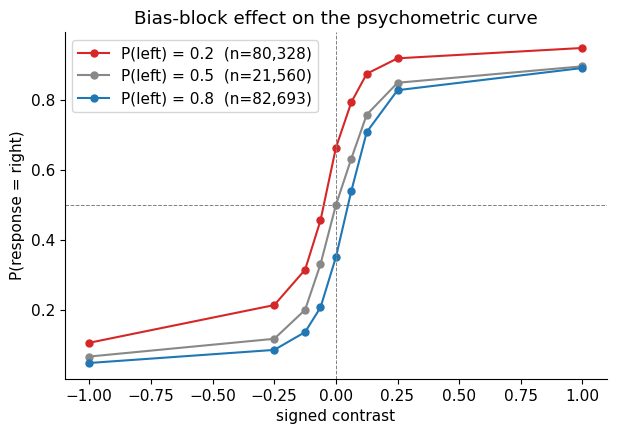

In [10]:
# --- Psychometric curve split by probability_left (trained phase)
trained = df[(df["phase"] == "trained") & df["response"].notna()].copy()
trained["pL"] = trained["probability_left"].round(2)
fig, ax = plt.subplots(figsize=(7, 4.5))
colours = {0.2: "#d62728", 0.5: "#888888", 0.8: "#1f77b4"}
for pL, color in colours.items():
    sub = trained[trained["pL"] == pL]
    if sub.empty:
        continue
    psy = sub.groupby("signed_contrast")["response"].mean()
    ax.plot(psy.index, psy.values, "o-", ms=5, color=color,
            label=f"P(left) = {pL}  (n={len(sub):,})")
ax.axhline(0.5, color="gray", lw=0.7, ls="--")
ax.axvline(0.0, color="gray", lw=0.7, ls="--")
ax.set_xlabel("signed contrast"); ax.set_ylabel("P(response = right)")
ax.set_title("Bias-block effect on the psychometric curve")
ax.legend()
plt.show()


## 7. No-go trials

No-go trials (`no_go = True`) are kept and flagged. They are rare for engaged
mice. Second data-cleaning exercise: students decide how to handle them.


In [11]:
# --- No-go counts
print("no-go trials total:", int(df["no_go"].sum()), f"({df['no_go'].mean()*100:.2f}%)")
print()
print("no-go rate per phase:")
print((df.groupby("phase")["no_go"].mean() * 100).round(2).astype(str) + " %")
print()
print("no-go count per subject:")
print(df[df["no_go"]].groupby("subject_id").size().sort_values(ascending=False).to_dict())


no-go trials total: 2904 (0.42%)

no-go rate per phase:
phase
trained     0.49 %
training    0.39 %
Name: no_go, dtype: str

no-go count per subject:
{'CSHL051': 238, 'NYU-11': 237, 'NYU-08': 199, 'CSP001': 184, 'CSP013': 171, 'CSHL054': 159, 'NYU-38': 151, 'NYU-28': 146, 'NYU-31': 129, 'CSHL053': 124, 'NYU-43': 111, 'NYU-56': 107, 'CSP016': 95, 'NYU-42': 89, 'CSHL046': 87, 'NYU-32': 68, 'NYU-50': 67, 'CSHL045': 55, 'CSHL060': 53, 'CSP011': 52, 'CSP029': 51, 'CSP023': 51, 'CSHL047': 50, 'CSP026': 42, 'CSP028': 42, 'CSHL055': 42, 'CSHL059': 30, 'CSP033': 29, 'CSP003': 27, 'CSHL049': 18}


## 8. Block-prior effect at zero contrast (trained phase)

On 0 %-contrast trials there is no visual evidence, so **P(response = right)** is
driven purely by the mouse's expectation. In the **trained** phase that
expectation is set by the **block prior**, so we split the zero-contrast trials
by block: left-biased (`probability_left` = 0.8) vs right-biased
(`probability_left` = 0.2). Every mouse chooses "right" more often in
right-biased blocks: a consistent within-subject effect, and a clean
illustration of prior use.

NB: We do *not* split the training phase: there `probability_left` is fixed at 0.5,
so there are no blocks. Note also that 0 %-contrast trials still have a defined
`correct` side (set by the block prior) so they are not "undefined" trials.

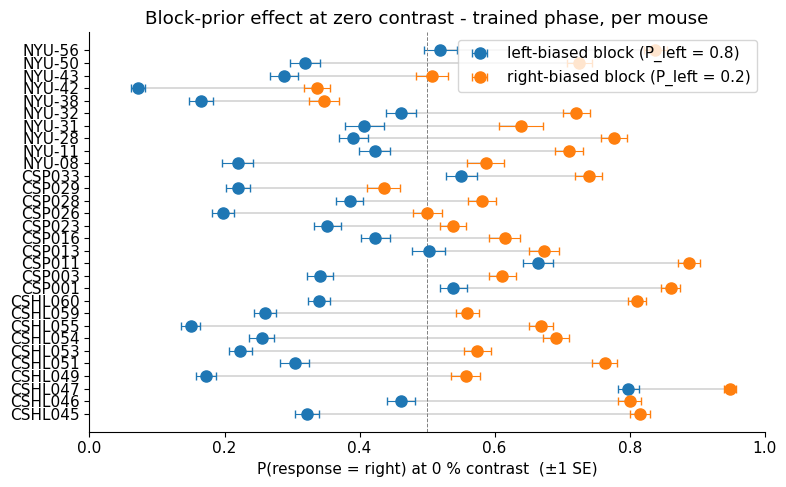

   subject_id  probability_left   p_right    n        se
0     CSHL045               0.2  0.814985  654  0.015184
1     CSHL045               0.8  0.321637  684  0.017860
2     CSHL046               0.2  0.800363  551  0.017029
3     CSHL046               0.8  0.461672  574  0.020808
4     CSHL047               0.2  0.948419  601  0.009022
5     CSHL047               0.8  0.797806  638  0.015901
6     CSHL049               0.2  0.557169  551  0.021161
7     CSHL049               0.8  0.172876  671  0.014598
8     CSHL051               0.2  0.762681  552  0.018108
9     CSHL051               0.8  0.303653  438  0.021972
10    CSHL053               0.2  0.574503  604  0.020118
11    CSHL053               0.8  0.223622  635  0.016535
12    CSHL054               0.2  0.690972  576  0.019254
13    CSHL054               0.8  0.254766  577  0.018140
14    CSHL055               0.2  0.668129  684  0.018005
15    CSHL055               0.8  0.149691  648  0.014015
16    CSHL059               0.2

In [12]:
# --- P(response = right) at zero contrast, split by block (TRAINED phase, per mouse)
zc = df[(df["phase"] == "trained") & (df["signed_contrast"] == 0) & df["response"].notna()]
blocks = {0.8: ("left-biased block (P_left = 0.8)",  "#1f77b4"),
          0.2: ("right-biased block (P_left = 0.2)", "#ff7f0e")}
bias = (zc[zc["probability_left"].isin(blocks)]
        .groupby(["subject_id", "probability_left"])
        .agg(p_right=("response", "mean"), n=("response", "size")).reset_index())
bias["se"] = np.sqrt(bias["p_right"] * (1 - bias["p_right"]) / bias["n"])

mice = sorted(bias["subject_id"].unique())
y = {m: i for i, m in enumerate(mice)}
fig, ax = plt.subplots(figsize=(8, 5))
for m in mice:
    g = bias[bias["subject_id"] == m]
    ax.plot(g["p_right"], [y[m]] * len(g), "-", color="lightgray", lw=1.2, zorder=1)
for pL, (label, color) in blocks.items():
    g = bias[bias["probability_left"] == pL]
    ax.errorbar(g["p_right"], [y[m] for m in g["subject_id"]], xerr=g["se"],
                fmt="o", color=color, ms=8, capsize=3, lw=0.8, label=label, zorder=2)
ax.axvline(0.5, color="gray", lw=0.7, ls="--")
ax.set_yticks(range(len(mice))); ax.set_yticklabels(mice)
ax.set_xlabel("P(response = right) at 0 % contrast  (±1 SE)")
ax.set_xlim(0, 1)
ax.set_title("Block-prior effect at zero contrast - trained phase, per mouse")
ax.legend()
plt.tight_layout(); plt.show()
print(bias)

## 9. Prior updating: two group differences and a non-difference

This is the main thing the earlier sections lead up to. For each mouse we take
one number, its **prior-updating shift**: how much P(response = right) at 0 %
contrast goes up when the block changes from left-biased (`P_left = 0.8`) to
right-biased (`P_left = 0.2`):

> `shift = P(right | P_left = 0.2) − P(right | P_left = 0.8)`

A large shift means the mouse leans on the prior when there is no visual
evidence; a small one means it mostly ignores it. We then compare this number
across three groupings, which gives a few ready examples for the t-test notebook:

- **genotype** (within the Angelaki lab): wild-type `NYU-…` vs Cntnap2 `CSP-…`,
  i.e. the ASD effect (Noel, Angelaki et al. 2025);
- **lab** (two wild-type cohorts): Churchland `CSHL-…` vs Angelaki `NYU-…`;
- **sex**: males vs females.

We keep the genotype comparison within a single lab on purpose: comparing
Churchland wild-types against Angelaki ASD mice would mix genotype with lab, and
(as the lab comparison shows) lab is not negligible here.


In [13]:
# --- Per-mouse prior-updating shift at 0 % contrast (trained phase)
zc = df[(df["phase"] == "trained") & (df["signed_contrast"] == 0) & df["response"].notna()]
pr = (zc[zc["probability_left"].isin([0.2, 0.8])]
      .groupby(["subject_id", "cohort", "probability_left"])["response"]
      .mean().unstack("probability_left")
      .rename(columns={0.2: "p_right_rblock", 0.8: "p_right_lblock"}))
pr["shift"] = pr["p_right_rblock"] - pr["p_right_lblock"]
pr = pr.reset_index()
pr.sort_values(["cohort", "shift"], ascending=[True, False]).round(3)


probability_left,subject_id,cohort,p_right_rblock,p_right_lblock,shift
7,CSHL055,CSHL-WT,0.668,0.150,0.518
0,CSHL045,CSHL-WT,0.815,0.322,0.493
9,CSHL060,CSHL-WT,0.811,0.340,0.471
4,CSHL051,CSHL-WT,0.763,0.304,0.459
6,CSHL054,CSHL-WT,0.691,0.255,0.436
3,CSHL049,CSHL-WT,0.557,0.173,0.384
5,CSHL053,CSHL-WT,0.575,0.224,0.351
1,CSHL046,CSHL-WT,0.800,0.462,0.339
8,CSHL059,CSHL-WT,0.559,0.260,0.299
2,CSHL047,CSHL-WT,0.948,0.798,0.151


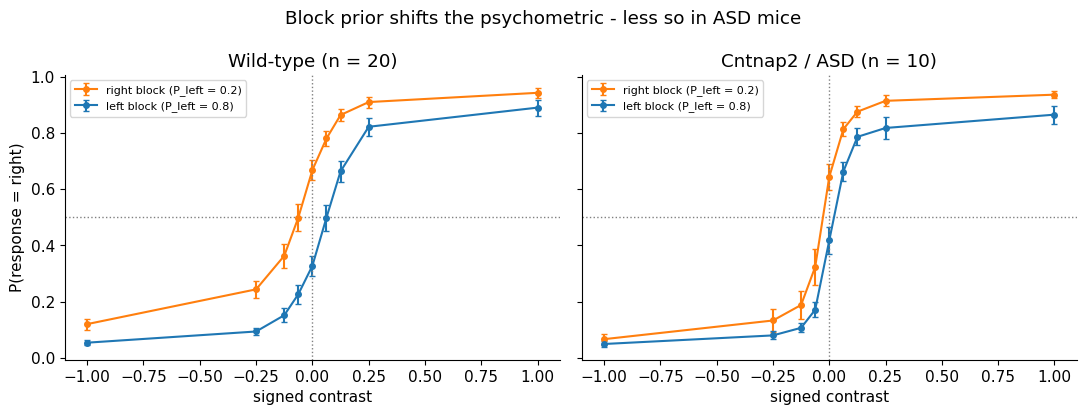

In [14]:
# --- Group psychometrics split by block: the blunted shift in ASD mice
def psychometric(sub):
    per_mouse = (sub.assign(is_right=(sub["response"] == 1).astype(float))
                    .groupby(["subject_id", "signed_contrast"])["is_right"].mean())
    return per_mouse.groupby("signed_contrast").agg(["mean", "sem"])

trained = df[(df["phase"] == "trained") & df["response"].notna()
             & df["probability_left"].isin([0.2, 0.8])]
blocks = {0.2: ("right block (P_left = 0.2)", "#ff7f0e"),
          0.8: ("left block (P_left = 0.8)",  "#1f77b4")}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (grp, title) in zip(axes, [("WT", "Wild-type (n = 20)"),
                                    ("ASD", "Cntnap2 / ASD (n = 10)")]):
    for pL, (label, color) in blocks.items():
        p = psychometric(trained[(trained["group"] == grp)
                                 & (trained["probability_left"] == pL)])
        ax.errorbar(p.index, p["mean"], yerr=p["sem"], marker="o", ms=4,
                    lw=1.5, capsize=2, color=color, label=label)
    ax.axhline(0.5, ls=":", c="gray", lw=1); ax.axvline(0, ls=":", c="gray", lw=1)
    ax.set_title(title); ax.set_xlabel("signed contrast")
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("P(response = right)")
fig.suptitle("Block prior shifts the psychometric - less so in ASD mice")
plt.tight_layout(); plt.show()


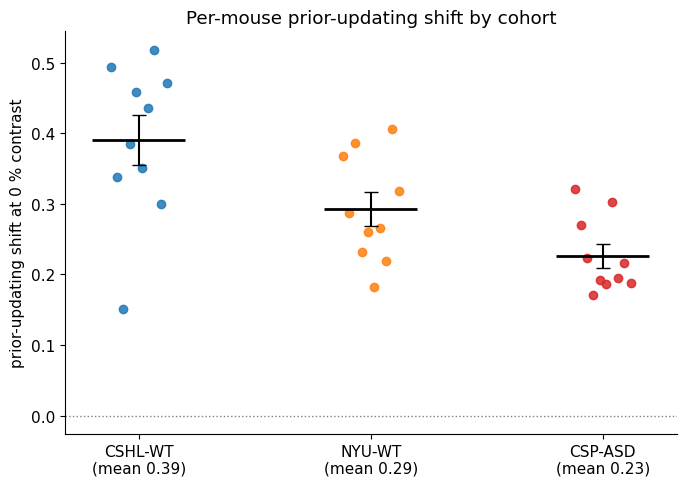

LAB      CSHL-WT vs NYU-WT  : 0.390 vs 0.292  Welch t=+2.31  p=0.0346  -> SIGNIFICANT
GENOTYPE NYU-WT  vs CSP-ASD : 0.292 vs 0.226  Welch t=+2.27  p=0.0375  -> SIGNIFICANT


In [15]:
# --- The two group comparisons on the per-mouse shift, with t-tests
def shift_of(c):
    return pr.loc[pr["cohort"] == c, "shift"].to_numpy()
cshl, nyu, csp = shift_of("CSHL-WT"), shift_of("NYU-WT"), shift_of("CSP-ASD")

fig, ax = plt.subplots(figsize=(7, 5))
for i, (name, v) in enumerate([("CSHL-WT", cshl), ("NYU-WT", nyu), ("CSP-ASD", csp)]):
    jitter = np.linspace(-0.12, 0.12, len(v))
    ax.scatter(np.full(len(v), i) + jitter, v, color=COHORT_COLOR[name],
               alpha=0.85, zorder=3)
    ax.hlines(v.mean(), i - 0.2, i + 0.2, color="black", lw=2, zorder=4)
    ax.errorbar(i, v.mean(), yerr=stats.sem(v), color="black", capsize=5, zorder=4)
ax.set_xticks(range(3))
ax.set_xticklabels([f"CSHL-WT\n(mean {cshl.mean():.2f})",
                    f"NYU-WT\n(mean {nyu.mean():.2f})",
                    f"CSP-ASD\n(mean {csp.mean():.2f})"])
ax.axhline(0, ls=":", c="gray", lw=1)
ax.set_ylabel("prior-updating shift at 0 % contrast")
ax.set_title("Per-mouse prior-updating shift by cohort")
plt.tight_layout(); plt.show()

t_lab, p_lab = stats.ttest_ind(cshl, nyu, equal_var=False)
t_gen, p_gen = stats.ttest_ind(nyu,  csp, equal_var=False)
print(f"LAB      CSHL-WT vs NYU-WT  : {cshl.mean():.3f} vs {nyu.mean():.3f}  "
      f"Welch t={t_lab:+.2f}  p={p_lab:.4f}  -> {'SIGNIFICANT' if p_lab < .05 else 'not significant'}")
print(f"GENOTYPE NYU-WT  vs CSP-ASD : {nyu.mean():.3f} vs {csp.mean():.3f}  "
      f"Welch t={t_gen:+.2f}  p={p_gen:.4f}  -> {'SIGNIFICANT' if p_gen < .05 else 'not significant'}")


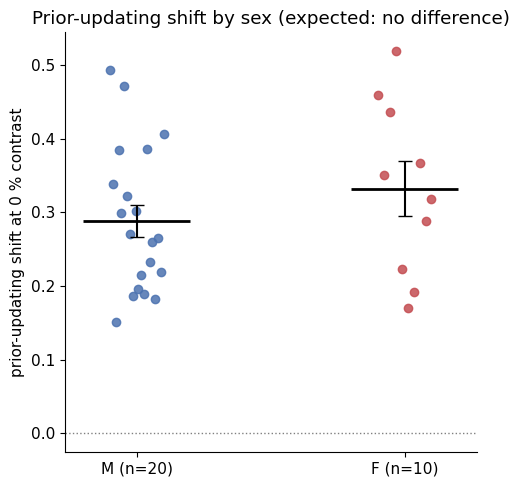

SEX  M vs F : 0.288 vs 0.332  Welch t=-1.02  p=0.3245  -> not significant


In [16]:
# --- A comparison with NO effect: prior-updating shift by sex
sex_of = subjects.set_index("subject_id")["sex"]
pr_sex = pr.assign(sex=pr["subject_id"].map(sex_of))
male   = pr_sex.loc[pr_sex["sex"] == "M", "shift"].to_numpy()
female = pr_sex.loc[pr_sex["sex"] == "F", "shift"].to_numpy()

fig, ax = plt.subplots(figsize=(5, 5))
for i, (name, v, c) in enumerate([("M", male, "#4c72b0"), ("F", female, "#c44e52")]):
    jitter = np.linspace(-0.1, 0.1, len(v))
    ax.scatter(np.full(len(v), i) + jitter, v, color=c, alpha=0.85, zorder=3)
    ax.hlines(v.mean(), i - 0.2, i + 0.2, color="black", lw=2, zorder=4)
    ax.errorbar(i, v.mean(), yerr=stats.sem(v), color="black", capsize=5, zorder=4)
ax.set_xticks([0, 1]); ax.set_xticklabels([f"M (n={len(male)})", f"F (n={len(female)})"])
ax.axhline(0, ls=":", c="gray", lw=1)
ax.set_ylabel("prior-updating shift at 0 % contrast")
ax.set_title("Prior-updating shift by sex (expected: no difference)")
plt.tight_layout(); plt.show()

t_sex, p_sex = stats.ttest_ind(male, female, equal_var=False)
print(f"SEX  M vs F : {male.mean():.3f} vs {female.mean():.3f}  "
      f"Welch t={t_sex:+.2f}  p={p_sex:.4f}  -> {'SIGNIFICANT' if p_sex < .05 else 'not significant'}")


**What we get.** Three comparisons on the same number:

- **genotype** (NYU-WT vs CSP-ASD, same lab): significant, the ASD mice shift
  less, the blunted-prior effect from Noel, Angelaki et al. (2025);
- **lab** (CSHL-WT vs NYU-WT, both wild-type): also significant, though modest, 
  even healthy mice differ a bit between labs, which is why we compare genotype
  within a lab and not across;
- **sex** (M vs F): not significant, a clean no-difference example.

So we have a real group difference and a genuine non-difference on the same
measure. Note that with 10 mice per cohort the lab and genotype p-values are not
far from 0.05 and can move if you drop a mouse, which is itself a good thing to
discuss with students (power and effect size).


## Notes for designing Notebooks 3-8

- **NB3 (descriptive stats)**: reaction-time distributions are a perfect
  mean-vs-median / skew / log-transform example; *and* `reaction_time_s` doubles
  as a data-cleaning exercise (negative + out-of-range values, IBL window).
- **NB4 (t-tests)**: ready-made comparisons (§9) on the prior-updating shift;
  **significant** (genotype: NYU-WT vs CSP-ASD, within lab) and
  **non-significant** (sex: M vs F); plus a modest **lab** effect (CSHL-WT vs
  NYU-WT) that motivates comparing within a lab; also a one-sample t-test
  (trained mice above 50 % chance at 0 % contrast).
- **NB5 (ANOVA / RM-ANOVA)**: `probability_left` is a genuine 3-level
  within-subject factor in the trained phase.
- **NB6-8 (non-parametrics, regression, mixed-effects)**: skewed RTs motivate
  rank tests / bootstrap; psychometric & chronometric curves motivate
  regression.

Dataset "messiness" to teach with: **raw reaction times**
(§4) and **no-go trials** (§7).
